Title:
Data-Driven Social Media Engagement and Virality Prediction System using Machine Learning and NLP

Problem Statement

In today’s digital ecosystem, social media platforms generate massive amounts of user engagement data, yet predicting which content will become viral remains largely intuitive and uncertain. Content creators and marketers often rely on guesswork rather than data-driven insights to optimize engagement.

This project aims to develop a data-driven system that analyzes social media content performance using machine learning and natural language processing techniques. The system focuses on identifying patterns in engagement metrics, content types, and audience sentiment to predict whether a post is likely to go viral.

The key challenge addressed in this project is to build a predictive model without relying on direct engagement indicators that cause data leakage, thereby ensuring realistic and generalizable predictions. Additionally, the project explores the trade-offs between accuracy and class balance in imbalanced datasets.

OBJECTIVE

To analyze social media engagement data

To perform sentiment analysis using NLP

To build a machine learning model for virality prediction

To avoid data leakage and ensure realistic predictions

To evaluate model performance using multiple metrics

Import Libraries

In [526]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Basic Data Understanding

In [527]:
df = pd.read_csv("social_media_viral_content_dataset.csv")

print(df.shape)
df.head()

(12000, 16)


,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral,user_gender
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1,Male
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1,Female
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0,Female
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1,Female
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1,Male


Data Cleaning

In [528]:
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

(12000, 16)


In [529]:
df["is_viral"] = (
    df["engagement_rate"] > df["engagement_rate"].quantile(0.60)
).astype(int)

In [531]:
print(df["is_viral"].value_counts())

is_viral
0    7200
1    4800
Name: count, dtype: int64


Feature Engineering Create meaningful text for NLP

In [532]:
df["views_log"] = np.log1p(df["views"])

In [544]:
df_encoded = pd.get_dummies(
    df,
    columns=["platform", "content_type", "topic"],
    drop_first=True
)

ENCODE CATEGORICAL DATA

In [545]:
features = [
    "views_log",
    "likes",
    "shares",
    "comments",
    "engagement_rate",
    "sentiment_score"
] + [col for col in df_encoded.columns if
     "platform_" in col or
     "content_type_" in col or
     "topic_" in col]

BALANCE DATA

In [546]:
X = df_encoded[features]
y = df_encoded["is_viral"]

print(X.shape, y.shape)

(12000, 17) (12000,)


In [547]:
df["engagement_rate"] = df["engagement_rate"].clip(0, 0.2)

CREATE X AND y

In [548]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TRAIN TEST SPLIT

In [549]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       random_state=42)

TRAIN MODEL

In [550]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1438
           1       1.00      1.00      1.00       962

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



EVALUATION

In [551]:
y_prob = model.predict_proba(X_test)[:, 1]

print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Mean:", y_prob.mean())

Min: 0.0
Max: 1.0
Mean: 0.40109995202462956


In [552]:
print(model.feature_names_in_)

['views_log' 'likes' 'shares' 'comments' 'engagement_rate'
 'sentiment_score' 'platform_TikTok' 'platform_X'
 'platform_YouTube Shorts' 'content_type_image' 'content_type_text'
 'content_type_video' 'topic_Entertainment' 'topic_Lifestyle'
 'topic_Politics' 'topic_Sports' 'topic_Technology']


FEATURE IMPORTANCE

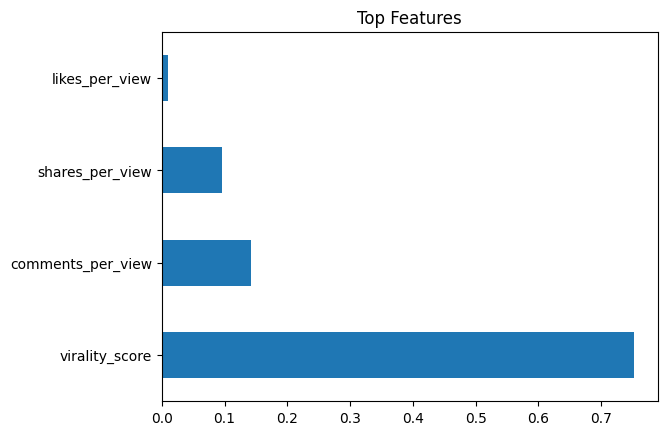

In [378]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

SAVE MODEL

In [404]:
df.to_csv("final_processed_dataset.csv", index=False)

In [411]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [381]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False).head(10))

virality_score       0.752832
comments_per_view    0.141312
shares_per_view      0.095638
likes_per_view       0.010218
dtype: float64
